In [8]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import spearmanr
import pandas as pd

In [9]:
def plot_deviation_per_sample_color(df, ground_truth, sample_index, importance_scores_dict, sequence_list, step_percent=10):
    """Plot deviation vs importance for COLOR model."""
    row = df.iloc[sample_index]
    original_sequence = sequence_list[sample_index]
    ground_truth_score = ground_truth[sample_index]
    
    x_vals, y_vals = [], []
    
    masked_seq_cols = [col for col in row.index if col.endswith(f'_{step_percent}%_masked_seq')]
    step_numbers = sorted([int(col.split('_')[0]) for col in masked_seq_cols])

    print(f"Sample {sample_index}: {original_sequence}")
    print(f"Ground Truth: {ground_truth_score[0]:.2f}")

    if sample_index not in importance_scores_dict:
        print(f"Warning: No scores for sample {sample_index}")
        return
    
    position_scores = importance_scores_dict[sample_index]

    for step in step_numbers:
        masked_seq = row[f"{step}_{step_percent}%_masked_seq"]
        masked_prop = row[f"{step}_{step_percent}%_instability"]
        
        if pd.isna(masked_seq) or pd.isna(masked_prop):
            continue
        
        masked_positions = [i for i, aa in enumerate(masked_seq) if aa == 'X' and i < len(original_sequence)]
        
        if masked_positions:
            scores = [position_scores[i] for i in masked_positions if i in position_scores]
            if scores:
                x_vals.append(np.mean(scores))
                y_vals.append(ground_truth_score[0] - masked_prop)

    if x_vals and y_vals:
        spearman_corr, p_value = spearmanr(x_vals, y_vals)
        
        plt.figure(figsize=(8, 5))
        plt.scatter(x_vals, y_vals, color='green', alpha=0.6, s=70)
        plt.plot(x_vals, y_vals, linestyle='--', alpha=0.5, color='gray')
        
        plt.xlabel('Mean COLOR Importance (Masked Positions)', fontsize=16)
        plt.ylabel('Deviation from Ground Truth', fontsize=16)
        plt.title(f'COLOR Model - Sample {sample_index}\nSpearman ρ = {spearman_corr:.3f}, p = {p_value:.4f}')
        plt.axhline(0, color='black', linestyle='-', linewidth=1, alpha=0.7)
        plt.tick_params(axis='both', labelsize=16)
        plt.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.savefig(f'COLOR_sample_{sample_index}.pdf', dpi=300, bbox_inches='tight')
        plt.show()

Saved → Figure_1_COLOR_masking.pdf
Saved → Figure_1_COLOR_masking.png


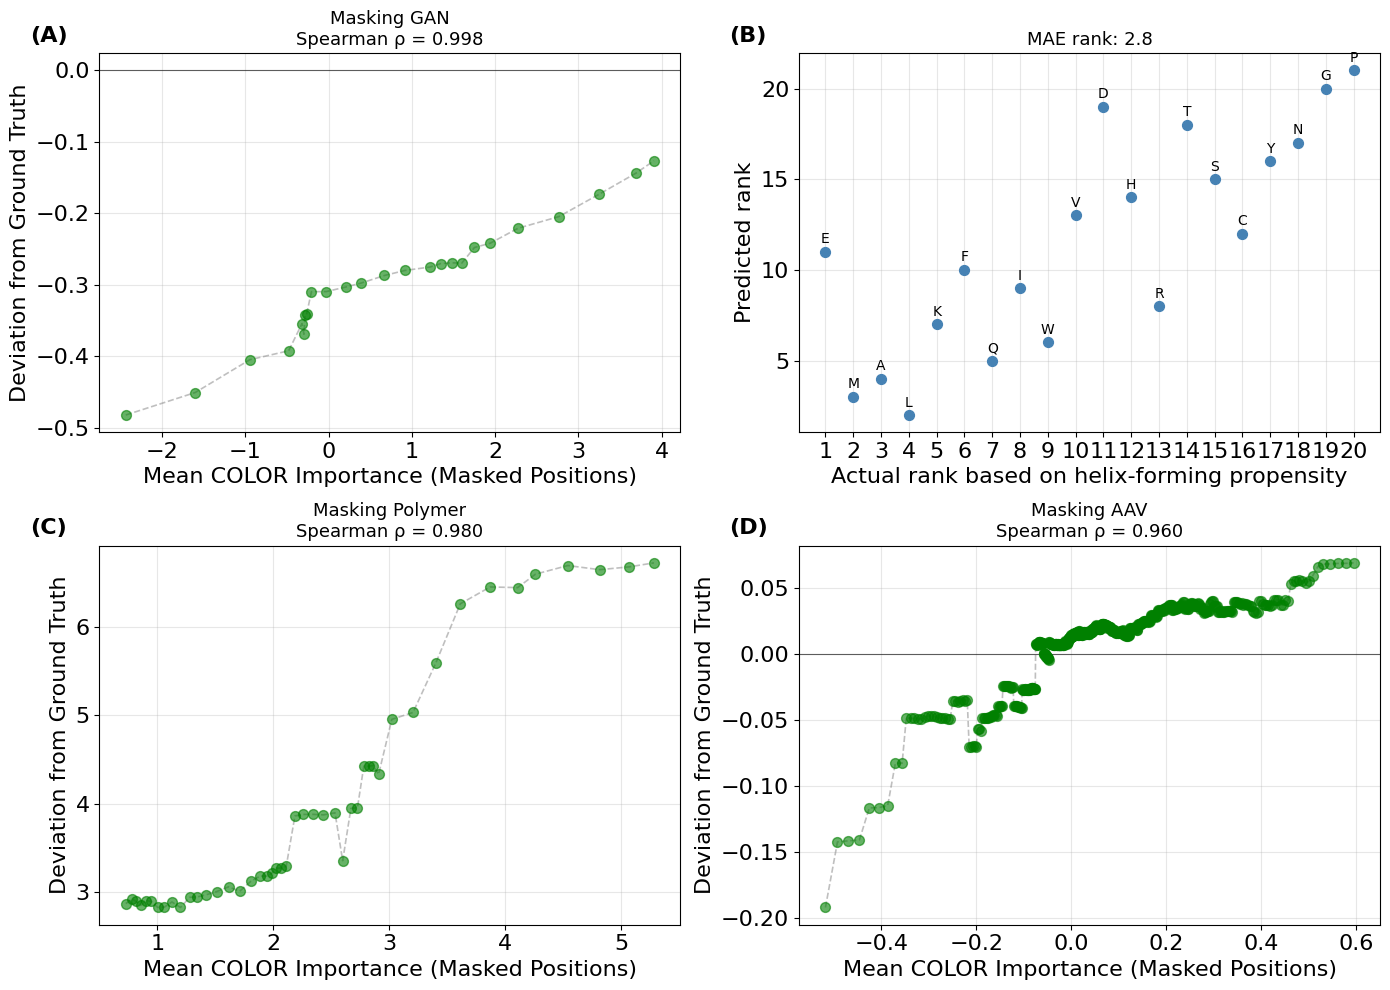

In [10]:
def plot_combined_4panel(
    gan_data_path,
    mae_data_path,
    polymer_data_path,
    aav_data_path,
    output_name='combined_4panel',
):
    """
    Assemble a 2x2 publication-ready figure from four saved .npy panel data files.

    Parameters
    ----------
    gan_data_path     : path to Max_GAN_panel_data.npy
    mae_data_path     : path to Max_MAE_panel_data.npy
    polymer_data_path : path to Max_Polymer_panel_data.npy
    aav_data_path     : path to Max_AAV_panel_data.npy
    output_name       : base name for saved PDF/PNG (no extension)
    """

    # ── Helper: compute x/y vals from saved data (mirrors your existing logic) ──
    def compute_xy(data, step_percent=10):
        df                            = data['df']
        ground_truth                  = data['ground_truth_instability']
        sample_index                  = int(data['idx_max'])
        importance_scores_dict        = data['Importance_values_position_specific']
        sequence_list                 = data['sequence_list']

        row                = df.iloc[sample_index]
        original_sequence  = sequence_list[sample_index]
        ground_truth_score = ground_truth[sample_index]
        position_scores    = importance_scores_dict[sample_index]

        masked_seq_cols = [c for c in row.index if c.endswith(f'_{step_percent}%_masked_seq')]
        step_numbers    = sorted([int(c.split('_')[0]) for c in masked_seq_cols])

        x_vals, y_vals = [], []
        for step in step_numbers:
            masked_seq  = row[f"{step}_{step_percent}%_masked_seq"]
            masked_prop = row[f"{step}_{step_percent}%_instability"]
            if pd.isna(masked_seq) or pd.isna(masked_prop):
                continue
            masked_positions = [i for i, aa in enumerate(masked_seq)
                                if aa == 'X' and i < len(original_sequence)]
            if masked_positions:
                scores = [position_scores[i] for i in masked_positions if i in position_scores]
                if scores:
                    x_vals.append(np.mean(scores))
                    y_vals.append(ground_truth_score[0] - masked_prop)

        return np.array(x_vals), np.array(y_vals)

    # ── Replace compute_xy_mae with this ──
    def compute_xy_mae(data):
        actual_rank  = data['actual_rank']
        pred_rank    = data['pred_rank']
        actual_order = data['actual_order'].tolist()
        mae          = float(data['mae'])
        return actual_rank, pred_rank, actual_order, mae

    # ── Load all panel data ──
    gan_data     = np.load(gan_data_path,     allow_pickle=True).item()
    mae_data = np.load('Max_MAE_panel_data.npy', allow_pickle=True).item()
    polymer_data = np.load(polymer_data_path, allow_pickle=True).item()
    aav_data = {
        'df': pd.concat([pd.read_csv(f'Max_AAV_df_part{i}.csv') for i in range(4)], ignore_index=True),
        'ground_truth_instability':            np.load('Max_AAV_ground_truth.npy', allow_pickle=True),
        'idx_max':                             int(np.load('Max_AAV_idx_max.npy', allow_pickle=True)),
        'Importance_values_position_specific': np.load('Max_AAV_importance_values.npy', allow_pickle=True).item(),
        'sequence_list':                       np.load('Max_AAV_sequence_list.npy', allow_pickle=True).tolist(),
    }
        
    x_gan,     y_gan              = compute_xy(gan_data)
    x_mae, y_mae, labels_mae, mae_val = compute_xy_mae(mae_data)
    x_polymer, y_polymer          = compute_xy(polymer_data)
    x_aav,     y_aav              = compute_xy(aav_data)

    rho_gan,     _ = spearmanr(x_gan,     y_gan)
    rho_polymer, _ = spearmanr(x_polymer, y_polymer)
    rho_aav,     _ = spearmanr(x_aav,     y_aav)

    # ── Figure layout ──
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    (ax_a, ax_b), (ax_c, ax_d) = axes

    panel_labels = ['(A)', '(B)', '(C)', '(D)']
    for ax, label in zip(axes.flat, panel_labels):
        ax.text(-0.12, 1.02, label, transform=ax.transAxes,
                fontsize=16, fontweight='bold', va='bottom', ha='left')

    # ── Panel A – Masking GAN ──
    sort_idx = np.argsort(x_gan)
    ax_a.scatter(x_gan, y_gan, color='green', alpha=0.6, s=50, zorder=3)
    ax_a.plot(x_gan[sort_idx], y_gan[sort_idx], linestyle='--', color='gray', alpha=0.5, linewidth=1.2)
    ax_a.axhline(0, color='black', linewidth=0.8, alpha=0.6)
    ax_a.set_title(f'Masking GAN\nSpearman ρ = {rho_gan:.3f}', fontsize=13)
    ax_a.set_xlabel('Mean COLOR Importance (Masked Positions)', fontsize=16)
    ax_a.set_ylabel('Deviation from Ground Truth', fontsize=16)
    ax_a.tick_params(axis='both', labelsize=16)
    ax_a.grid(True, alpha=0.3)

    # ── Panel B – MAE rank (replace the Panel B block) ──
    ax_b.scatter(x_mae, y_mae, color='steelblue', s=50, zorder=3)
    for x, y, label in zip(x_mae, y_mae, labels_mae):
        ax_b.text(x, y + 0.3, label, ha='center', va='bottom', fontsize=10)
    ax_b.set_title(f'MAE rank: {mae_val:.1f}', fontsize=13)
    ax_b.set_xlabel('Actual rank based on helix-forming propensity', fontsize=16)
    ax_b.set_ylabel('Predicted rank', fontsize=16)
    ax_b.set_xticks(x_mae)
    ax_b.tick_params(axis='both', labelsize=16)
    ax_b.grid(True, alpha=0.3)

    # ── Panel C – Masking Polymer ──
    sort_idx = np.argsort(x_polymer)
    ax_c.scatter(x_polymer, y_polymer, color='green', alpha=0.6, s=50, zorder=3)
    ax_c.plot(x_polymer[sort_idx], y_polymer[sort_idx], linestyle='--', color='gray', alpha=0.5, linewidth=1.2)
    ax_c.set_title(f'Masking Polymer\nSpearman ρ = {rho_polymer:.3f}', fontsize=13)
    ax_c.set_xlabel('Mean COLOR Importance (Masked Positions)', fontsize=16)
    ax_c.set_ylabel('Deviation from Ground Truth', fontsize=16)
    ax_c.tick_params(axis='both', labelsize=16)
    ax_c.grid(True, alpha=0.3)

    # ── Panel D – Masking AAV ──
    sort_idx = np.argsort(x_aav)
    ax_d.scatter(x_aav, y_aav, color='green', alpha=0.6, s=50, zorder=3)
    ax_d.plot(x_aav[sort_idx], y_aav[sort_idx], linestyle='--', color='gray', alpha=0.5, linewidth=1.2)
    ax_d.axhline(0, color='black', linewidth=0.8, alpha=0.6)
    ax_d.set_title(f'Masking AAV\nSpearman ρ = {rho_aav:.3f}', fontsize=13)
    ax_d.set_xlabel('Mean COLOR Importance (Masked Positions)', fontsize=16)
    ax_d.set_ylabel('Deviation from Ground Truth', fontsize=16)
    ax_d.tick_params(axis='both', labelsize=16)
    ax_d.grid(True, alpha=0.3)

    plt.tight_layout()

    for ext in ['pdf', 'png']:
        plt.savefig(f'{output_name}.{ext}', dpi=300, bbox_inches='tight')
        print(f"Saved → {output_name}.{ext}")

    plt.show()


plot_combined_4panel(
    gan_data_path     = 'Max_GAN_panel_data.npy',
    mae_data_path     = 'Max_MAE_panel_data.npy',
    polymer_data_path = 'Max_Polymer_panel_data.npy',
    aav_data_path     = 'Max_AAV_panel_data.npy',
    output_name       = 'Figure_1_COLOR_masking',
)

In [11]:
def plot_combined_2panel(
    aromatic_data_path,
    aliphatic_data_path,
    output_name='combined_2panel',
):
    def compute_xy(data, step_percent=10, prop_col='instability'):
        df                     = data['df']
        ground_truth           = data['ground_truth_instability']
        sample_index           = int(data['idx_max'])
        raw                    = data['Importance_values_position_specific']
        importance_scores_dict = raw.item() if hasattr(raw, 'item') else raw
        sequence_list          = data['sequence_list']

        row                = df.iloc[sample_index]
        original_sequence  = sequence_list[sample_index]
        ground_truth_score = ground_truth[sample_index]

        # ground_truth_score may be scalar or array depending on the notebook
        if hasattr(ground_truth_score, '__len__'):
            ground_truth_score = ground_truth_score[0]

        position_scores = importance_scores_dict[sample_index]

        masked_seq_cols = [c for c in row.index if c.endswith(f'_{step_percent}%_masked_seq')]
        step_numbers    = sorted([int(c.split('_')[0]) for c in masked_seq_cols])

        x_vals, y_vals = [], []
        for step in step_numbers:
            masked_seq  = row[f"{step}_{step_percent}%_masked_seq"]
            masked_prop = row[f"{step}_{step_percent}%_{prop_col}"]   # ← uses prop_col
            if pd.isna(masked_seq) or pd.isna(masked_prop):
                continue
            masked_positions = [i for i, aa in enumerate(masked_seq)
                                if aa == 'X' and i < len(original_sequence)]
            if masked_positions:
                scores = [position_scores[i] for i in masked_positions if i in position_scores]
                if scores:
                    x_vals.append(np.mean(scores))
                    y_vals.append(ground_truth_score - masked_prop)

        return np.array(x_vals), np.array(y_vals)

    # ── Load ──
    aromatic_data  = np.load(aromatic_data_path,  allow_pickle=True).item()
    aliphatic_data = np.load(aliphatic_data_path, allow_pickle=True).item()

    x_ar,  y_ar  = compute_xy(aromatic_data,  prop_col='gravy')
    x_al,  y_al  = compute_xy(aliphatic_data, prop_col='aliphatic')

    rho_ar, _ = spearmanr(x_ar, y_ar)
    rho_al, _ = spearmanr(x_al, y_al)

    # ── Figure ──
    fig, (ax_a, ax_b) = plt.subplots(1, 2, figsize=(14, 5))

    panel_labels = ['(A)', '(B)']
    for ax, label in zip([ax_a, ax_b], panel_labels):
        ax.text(-0.12, 1.02, label, transform=ax.transAxes,
                fontsize=16, fontweight='bold', va='bottom', ha='left')

    # ── Panel A – Aromatic ──
    sort_idx = np.argsort(x_ar)
    ax_a.scatter(x_ar, y_ar, color='green', alpha=0.6, s=50, zorder=3)
    ax_a.plot(x_ar[sort_idx], y_ar[sort_idx], linestyle='--', color='gray', alpha=0.5, linewidth=1.2)
    ax_a.axhline(0, color='black', linewidth=0.8, alpha=0.6)
    ax_a.set_title(f'Masking Aromatic\nSpearman ρ = {rho_ar:.3f}', fontsize=13)
    ax_a.set_xlabel('Mean COLOR Importance (Masked Positions)', fontsize=16)
    ax_a.set_ylabel('Deviation from Ground Truth', fontsize=16)
    ax_a.tick_params(axis='both', labelsize=16)
    ax_a.grid(True, alpha=0.3)

    # ── Panel B – Aliphatic ──
    sort_idx = np.argsort(x_al)
    ax_b.scatter(x_al, y_al, color='green', alpha=0.6, s=50, zorder=3)
    ax_b.plot(x_al[sort_idx], y_al[sort_idx], linestyle='--', color='gray', alpha=0.5, linewidth=1.2)
    ax_b.axhline(0, color='black', linewidth=0.8, alpha=0.6)
    ax_b.set_title(f'Masking Aliphatic\nSpearman ρ = {rho_al:.3f}', fontsize=13)
    ax_b.set_xlabel('Mean COLOR Importance (Masked Positions)', fontsize=16)
    ax_b.set_ylabel('Deviation from Ground Truth', fontsize=16)
    ax_b.tick_params(axis='both', labelsize=16)
    ax_b.grid(True, alpha=0.3)

    plt.tight_layout()

    for ext in ['pdf', 'png']:
        plt.savefig(f'{output_name}.{ext}', dpi=300, bbox_inches='tight')
        print(f"Saved → {output_name}.{ext}")

    plt.show()


Saved → Figure_2_Gravy_Aliphatic.pdf
Saved → Figure_2_Gravy_Aliphatic.png


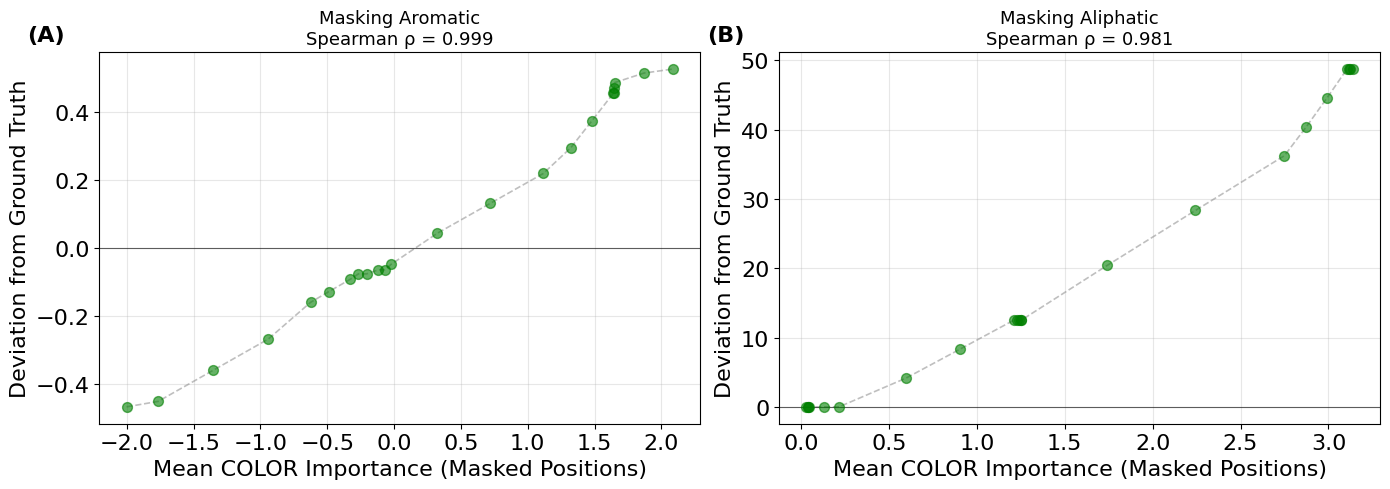

In [12]:
plot_combined_2panel(
    aromatic_data_path  = 'Max_Gravy_Panel_Data.npy',
    aliphatic_data_path = 'Max_aliphatic_Panel_Data.npy',
    output_name         = 'Figure_2_Gravy_Aliphatic',
)

In [13]:
data_al = np.load('Max_aliphatic_Panel_Data.npy', allow_pickle=True).item()
print(data_al.keys())
print(type(data_al['ground_truth_instability']))
print(data_al['ground_truth_instability'][int(data_al['idx_max'])])

dict_keys(['df', 'ground_truth_instability', 'idx_max', 'Importance_values_position_specific', 'sequence_list'])
<class 'numpy.ndarray'>
162.91666666666666


In [14]:
data = np.load('Max_Gravy_Panel_Data.npy', allow_pickle=True).item()
print(data.keys())


dict_keys(['df', 'ground_truth_instability', 'idx_max', 'Importance_values_position_specific', 'sequence_list'])
